# Asymmetric state set

In [1]:
import sys
sys.path.append("../")

In [2]:
# imports
from flow.solve_mix import *
from flow.build_circuits import *  # Takes some time to import
from utils.sic_fiducial_state import *
from utils.inner_product import *
from utils.handy_states import *
from utils.inner_product import inner_products_table
from utils.multiple_wigner import plot_multiple_wigner
from utils.complex_heatmap import ComplexHeatmap
c_heatmap = ComplexHeatmap()

In [3]:
# Input states
num_qubits = 2
num_states = 3
# num_qubits = 2
# state_vec = sv_sic_asymm_small()["states"]
# state_vec, qutip_states = sv_coh_asymm_small(num_qubits=num_qubits)
state_vec = sv_simple_2()["states"]

In [4]:
inner_products_table([item.data for item in state_vec])
print()


Inner Product Table:
----------------------------------------------------------------------
|  States   |     State 0      |     State 1      |     State 2      |
--------------------------------------------------------------------
|  State 0  |    1.000e+00     |    1.636e-02     |    1.951e-02     |
|  State 1  |    1.636e-02     |    1.000e+00     |    3.224e-02     |
|  State 2  |    1.951e-02     |    3.224e-02     |      1.e+00      |
----------------------------------------------------------------------



In [5]:
dense_mat = [DensityMatrix(_) for _ in state_vec]

problem_asymm_states_1 = ProblemSpec(
    num_qubits=num_qubits,
    num_states=num_states,
    seed=33,
    case_id=f"q{num_qubits}_n{num_states}_symm",
    state_type="statevector",
)
problem_asymm_states_1.set_states(
    state_type="statevector",
    states=state_vec,
    overwrite=True,
)
print("Is linear indep", problem_asymm_states_1.is_lin_indep())
ideal_result = apply_Eldar(problem_spec=problem_asymm_states_1)

print(verify_povm_matrix(ideal_result["povm"]))
p_inc_ideal = ideal_result["p_inc"]


Rank = 3
#states = 3
Is linear indep True
<class 'numpy.ndarray'>
shape = (4, 4)
[[ 9.8153e-01+0.j -1.5320e-02+0.j -1.8385e-02+0.j  9.1923e-02+0.j]
 [-1.5320e-02-0.j  2.3913e-04+0.j  2.8696e-04+0.j -1.4348e-03-0.j]
 [-1.8385e-02-0.j  2.8696e-04+0.j  3.4435e-04+0.j -1.7218e-03-0.j]
 [ 9.1923e-02+0.j -1.4348e-03+0.j -1.7218e-03+0.j  8.6088e-03+0.j]]
<class 'numpy.ndarray'>
shape = (4, 4)
[[ 2.3913e-04+0.j -1.5065e-02-0.j  4.7827e-04+0.j -2.3913e-03-0.j]
 [-1.5065e-02+0.j  9.4912e-01+0.j -3.0131e-02+0.j  1.5065e-01+0.j]
 [ 4.7827e-04+0.j -3.0131e-02-0.j  9.5653e-04+0.j -4.7827e-03-0.j]
 [-2.3913e-03+0.j  1.5065e-01+0.j -4.7827e-03+0.j  2.3913e-02+0.j]]
<class 'numpy.ndarray'>
shape = (4, 4)
[[ 3.4435e-04+0.j  5.7392e-04+0.j -1.7868e-02-0.j -3.4435e-03-0.j]
 [ 5.7392e-04+0.j  9.5653e-04+0.j -2.9780e-02-0.j -5.7392e-03-0.j]
 [-1.7868e-02+0.j -2.9780e-02+0.j  9.2715e-01+0.j  1.7868e-01+0.j]
 [-3.4435e-03+0.j -5.7392e-03+0.j  1.7868e-01+0.j  3.4435e-02+0.j]]
<class 'numpy.ndarray'>
shape = (4

In [6]:
print(np.multiply(ideal_result['sol'], 1/3))
print(sum(np.multiply(ideal_result['sol'], 1/3)))

[0.33   0.3243 0.3205]
0.9748701230323088


In [7]:
## plot_multiple_wigner(
##     states=qutip_states,
##     projection="2d",
##     colors=["blue", "red", "green", "yellow"],
##     linestyles=["-", "--", ":", "-"],
##     colorbar=True,
##     use_filled=False,
##     # save_path="coherent_states_wigner_contours.png",
##     close_fig=False,
## )

In [8]:
len(ideal_result["povm"])

4

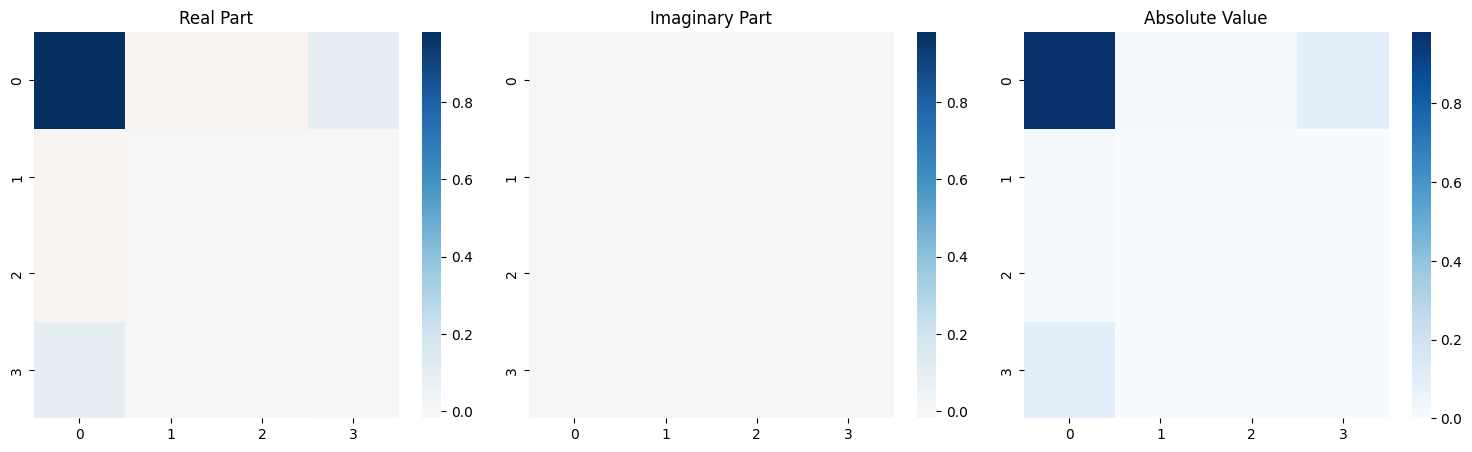

In [9]:
c_heatmap.plot(
    ideal_result["povm"][0],
    annot=False,
    # title=r"Coherent state, N=32, $|\alpha|$=8, $\angle{\alpha}=\pi/4$",
    show_phase=False,
)

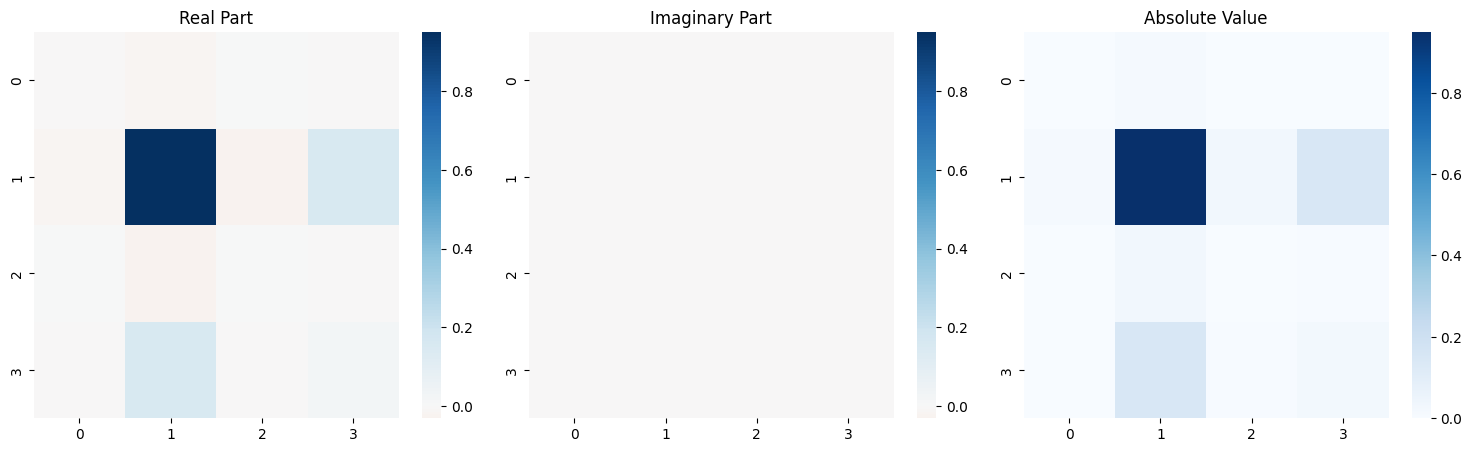

In [10]:
c_heatmap.plot(
    ideal_result["povm"][1],
    annot=False,
    # title=r"Coherent state, N=32, $|\alpha|$=8, $\angle{\alpha}=\pi/4$",
    show_phase=False,
)

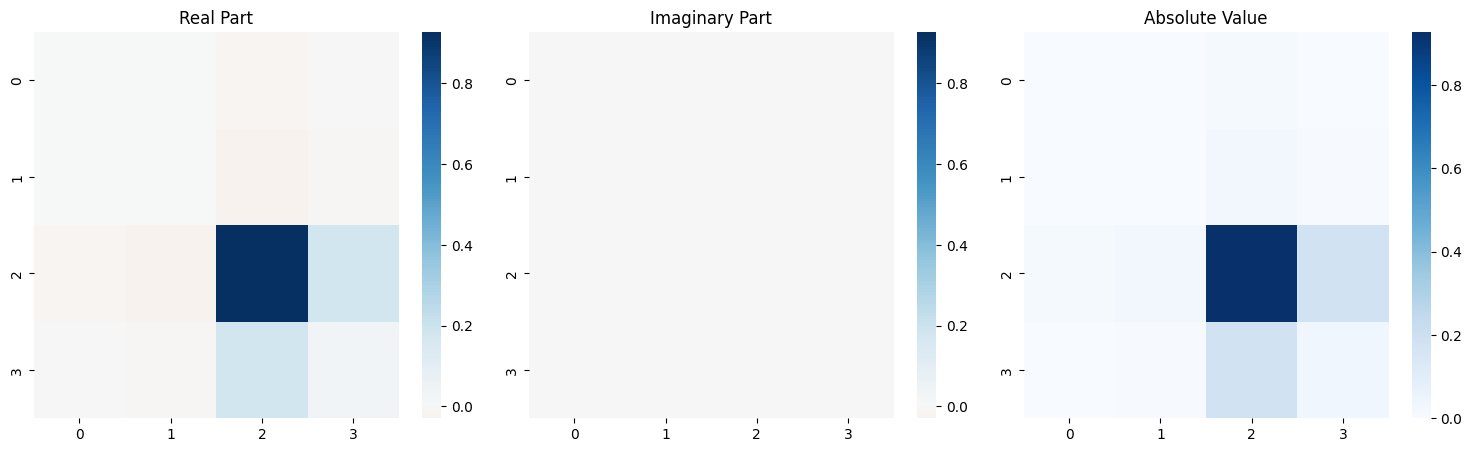

In [11]:
c_heatmap.plot(
    ideal_result["povm"][2],
    annot=False,
    # title=r"Coherent state, N=32, $|\alpha|$=8, $\angle{\alpha}=\pi/4$",
    show_phase=False,
)

In [12]:
obj = POVMCircuit(povm_vectors=ideal_result["povm_vectors"])
obj.num_qubits = num_qubits
obj.num_amps = 2 ** num_qubits
obj.case_id = f"simple_asymm_ideal_q{num_qubits}_n3"
obj.fix()
obj.build_circuit()

In [13]:
qc = QuantumCircuit.from_qasm_file(
    f"qc_iso_simple_asymm_ideal_q{num_qubits}_n3_no_backend.qasm"
)
print(qc.count_ops())
print(qc.depth())

OrderedDict({'u': 61, 'cx': 47, 'u1': 2})
92


In [14]:
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(10)]
disturbance_states = [
    DensityMatrix(
        ProblemSpec.depolarizing_noise_channel(num_qubits=num_qubits)
    )
    for _ in range(num_states)
]

In [15]:
noise_level = noise_levels[6]
combined_states = [
    (1 - noise_level) * dense_mat[_]
    + noise_level * disturbance_states[_].data
    for _ in range(num_states)
]
problem_asymm_states_1.set_states(
    state_type="densitymatrix",
    states=combined_states,
    overwrite=True,
)

# noisy_result = apply_Eldar_mix_primal(
#     problem_spec=problem_asymm_states_1,
#     beta=p_inc_ideal,
#     is_cvxpy_verbose=False,
# )

In [16]:
# Noisy results of POVM designed by ideal assumption
m = calculate_prob_matrix_simple(problem_asymm_states_1.prior_prob, ideal_result["povm"], combined_states)
for i in m:
    print(i)

[0.3297855209341643, 8.118556412388057e-05, 8.024054881003846e-05, 0.0033863862862351817]
[8.256013507868706e-05, 0.3240811740447993, 8.024054881003847e-05, 0.009089358604645385]
[8.256013507868704e-05, 8.118556412388055e-05, 0.3202725441783255, 0.01289704345580517]


In [17]:
# Previous work with noise


In [18]:
# Our formulation
our_result = apply_crossQD(
    problem_spec=problem_asymm_states_1,
    # prior_prob=None,
    alpha=[0.001] * num_states,
    beta=[0.001] * num_states,
    is_cvxpy_verbose=False,
)

Result = 0.999056398367478
CVXPY returns optimal
Probabilities for each state:
[np.float64(0.33304816260264825), np.float64(0.00014968636617914872), np.float64(0.00014781744612699766), np.float64(4.283373928134356e-07)]
[np.float64(0.00012705967989502814), np.float64(0.33300591020472625), np.float64(0.00020065156283912433), np.float64(4.229563592524122e-07)]
[np.float64(0.00013163996239508953), np.float64(0.00020312339435047495), np.float64(0.33300233219899933), np.float64(4.2263701328237685e-07)]
Total probability = 1.0000
Success probability = 0.9991
Inconclusive probability = 0.0000



In [19]:
# TODO Small scan and observe
# TODO Big search and observe

In [20]:
# Our formulation
our_result = apply_crossQD(
    problem_spec=problem_asymm_states_1,
    # prior_prob=None,
    alpha=[0.01, 0.1, 0.01],
    beta=[0.01, 0.1, 0.01],
    is_cvxpy_verbose=False,
)

Result = 0.999052583305734
CVXPY returns optimal
Probabilities for each state:
[np.float64(0.33305646453600984), np.float64(0.0001347359085250844), np.float64(0.00014211616168763834), np.float64(4.92259400466215e-10)]
[np.float64(0.0001325973262801752), np.float64(0.3330039529643746), np.float64(0.0001968523161438307), np.float64(6.952637699078718e-08)]
[np.float64(0.0001421425719347993), np.float64(0.0001990173915092216), np.float64(0.33299216580534946), np.float64(1.3458574726359763e-09)]
Total probability = 1.0000
Success probability = 0.9991
Inconclusive probability = 0.0000



In [21]:
# Our formulation
our_result = apply_crossQD(
    problem_spec=problem_asymm_states_1,
    # prior_prob=None,
    alpha=[0.01, 0.01, 0.01],
    beta=[0.01, 0.01, 0.01],
    is_cvxpy_verbose=False,
)

Result = 0.9990560852914954
CVXPY returns optimal
Probabilities for each state:
[np.float64(0.33305844284027175), np.float64(0.00013317044733588532), np.float64(0.00014257657742110694), np.float64(5.813846324271027e-08)]
[np.float64(0.0001331866808886268), np.float64(0.3330035504014304), np.float64(0.00019743174486487353), np.float64(5.356304672920637e-08)]
[np.float64(0.00014261504921138), np.float64(0.00019745398432610342), np.float64(0.3329940929661472), np.float64(5.2356327468496415e-08)]
Total probability = 1.0000
Success probability = 0.9991
Inconclusive probability = 0.0000

